# Build the relationship/damage function between hydro std anomaly and SPI6

SPI3/SPI6/monthly precipitation have all been tested, SPI 6 wins as the r squared value and p-value perform the best to fit hydro anomaly.
SPI6 is calculated using a gamma distribution.



Regression equation:
y = 0.0785 + 1.2567 * x0 + -0.2899 * x1 + -0.5183 * x2 + -0.1252 * x3


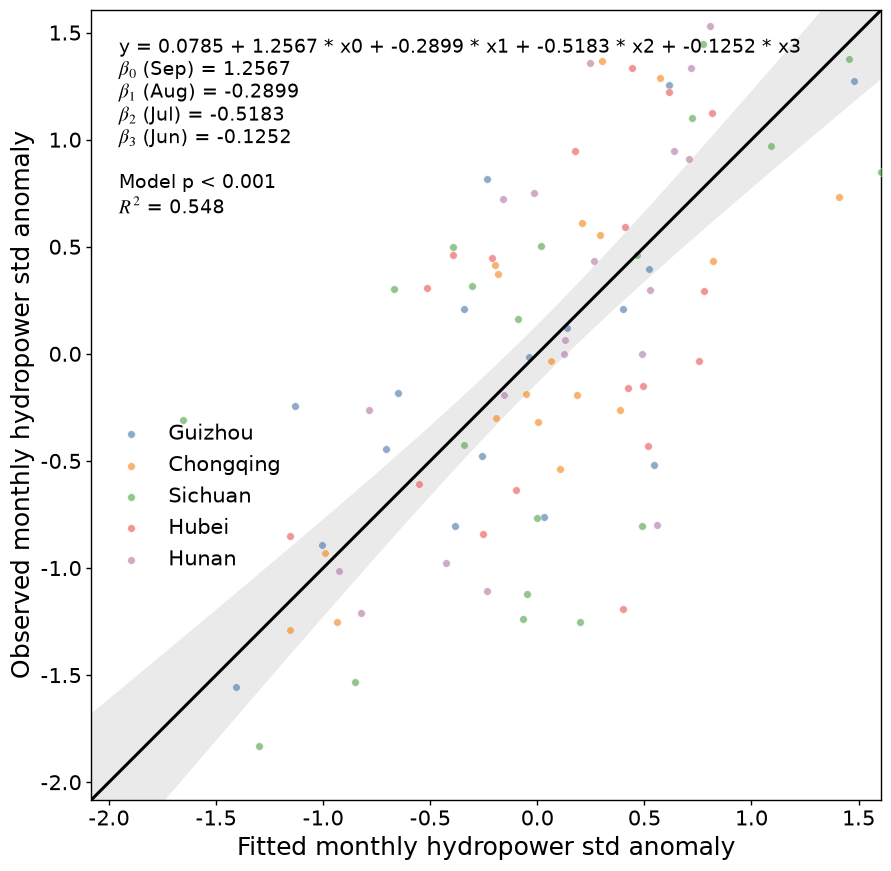

In [1]:
import calendar
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from pathlib import Path

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# 1. 用户参数
# ============================================================

INPUT_DIR = ("/home/users/weijia_6/Yangtze_code/gen_data/hydropower_anomaly")

PROVINCE_INFO = {
    "guizhou": {"name": "Guizhou", "panel": "(a)", "color": "#4C78A8"},
    "chongqing": {"name": "Chongqing", "panel": "(b)", "color": "#F58518"},
    "sichuan": {"name": "Sichuan", "panel": "(c)", "color": "#54A24B"},
    "hubei": {"name": "Hubei", "panel": "(d)", "color": "#E45756"},
    "hunan": {"name": "Hunan", "panel": "(e)", "color": "#B279A2"},
}

YEAR_START = 2002
YEAR_END = 2022
TARGET_MONTH = 9
TIME_LAG = 3

HYDRO_ANOMALY_COL = "std_anomaly"
PRECIP_ANOMALY_COL = "spi_6"

# Output folder
out_dir = Path("/home/users/weijia_6/Yangtze_code/gen_result")
out_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2. 参数检查
# ============================================================

if not isinstance(TARGET_MONTH, int) or isinstance(TARGET_MONTH, bool):
    raise ValueError("TARGET_MONTH 必须是1—12之间的整数。")

if TARGET_MONTH < 1 or TARGET_MONTH > 12:
    raise ValueError("TARGET_MONTH 必须是1—12之间的整数。")

if not isinstance(TIME_LAG, int) or isinstance(TIME_LAG, bool) or TIME_LAG < 0:
    raise ValueError("TIME_LAG 必须是非负整数，例如0、1、2或3。")

if TIME_LAG > TARGET_MONTH - 1:
    raise ValueError(
        f"TARGET_MONTH={TARGET_MONTH} 时，TIME_LAG不能大于 {TARGET_MONTH - 1}。"
    )

LAG_LIST = list(range(TIME_LAG + 1))
LAG_COLS = [f"{PRECIP_ANOMALY_COL}_lag{lag}" for lag in LAG_LIST]
N_LAG_TERMS = len(LAG_COLS)

# ============================================================
# 3. 图形参数
# ============================================================

FIGSIZE = (14, 10)
FIGURE_DPI = 600

SCATTER_SIZE = 30
SCATTER_ALPHA = 0.62
SCATTER_EDGE_WIDTH = 0.45

CALIBRATION_LINE_WIDTH = 2.2
REFERENCE_LINE_WIDTH = 1.3
CONFIDENCE_ALPHA = 0.18

# TITLE_FONT_SIZE = 13
# LABEL_FONT_SIZE = 11
# TICK_FONT_SIZE = 9.5

TITLE_FONT_SIZE = 18
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
ANNOTATION_FONT_SIZE = 14

SHOW_95_CI = True
SHOW_GRID = False

# ANNOTATION_FONT_SIZE = max(7.2, 9.1 - 0.35 * TIME_LAG)

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",#DejaVu Serif",
        "font.size": 15,
        "axes.unicode_minus": False,
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.0,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
    }
)

# ============================================================
# 4. 通用辅助函数
# ============================================================

def assert_exists(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到路径：\n{path}")

def construct_month_date(df):
    return pd.to_datetime(
        {"year": df["year"], "month": df["month"], "day": 1},
        errors="coerce",
    )

def month_number_for_lag(lag):
    return TARGET_MONTH - lag

def month_name_for_lag(lag):
    return calendar.month_name[month_number_for_lag(lag)]

def target_month_name():
    return calendar.month_name[TARGET_MONTH]

def rainfall_window_text():
    start_month = month_name_for_lag(TIME_LAG)
    end_month = target_month_name()
    if TIME_LAG == 0:
        return end_month
    return f"{start_month}-{end_month}"

def significance_label(p):
    if not np.isfinite(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

def format_p_value(p):
    if not np.isfinite(p):
        return "NA"
    if p < 0.001:
        return "< 0.001"
    return f"= {p:.3f}"

def format_coefficient(value):
    if not np.isfinite(value):
        return "NA"
    abs_value = abs(value)
    if (0 < abs_value < 0.001) or abs_value >= 1000:
        return f"{value:.2e}"
    return f"{value:.4f}"

def beta_display_name(lag):
    return rf"$\beta_{{{lag}}}$"

# ============================================================
# 5. 替代 Statsmodels：OLS + t/p/CI
# ============================================================

def fit_ols(y, X):
    n = len(y)
    X = np.column_stack([np.ones(n), X])  # add constant
    model = LinearRegression(fit_intercept=False).fit(X, y)

    coef = model.coef_
    fitted = model.predict(X)
    residuals = y - fitted
    rss = np.sum(residuals**2)
    df = n - X.shape[1]

    XtX_inv = np.linalg.inv(X.T @ X)
    sigma2 = rss / df
    stderr = np.sqrt(np.diag(sigma2 * XtX_inv))

    tval = coef / stderr
    pval = 2 * (1 - stats.t.cdf(np.abs(tval), df))

    ci_low = coef - stats.t.ppf(0.975, df) * stderr
    ci_high = coef + stats.t.ppf(0.975, df) * stderr

    r2 = model.score(X, y)

    return {
        "coef": coef,
        "stderr": stderr,
        "tval": tval,
        "pval": pval,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "fitted": fitted,
        "residuals": residuals,
        "r2": r2,
    }

def durbin_watson(residuals):
    diff = np.diff(residuals)
    return np.sum(diff**2) / np.sum(residuals**2)

def calculate_vif(X):
    vif_list = []
    for i in range(X.shape[1]):
        y = X[:, i]
        X_others = np.delete(X, i, axis=1)
        model = LinearRegression().fit(X_others, y)
        r2 = model.score(X_others, y)
        vif = 1.0 / (1.0 - r2)
        vif_list.append(vif)
    return vif_list

# ============================================================
# 6. Overall model p-value (single p-value)
# ============================================================

def overall_model_pvalue(result, X, y):
    n = len(y)
    k = X.shape[1]

    fitted = result["fitted"]
    residuals = result["residuals"]

    rss = np.sum(residuals**2)
    tss = np.sum((y - np.mean(y))**2)
    reg_ss = tss - rss

    df_reg = k
    df_resid = n - (k + 1)

    ms_reg = reg_ss / df_reg
    ms_resid = rss / df_resid

    F = ms_reg / ms_resid
    p = 1 - stats.f.cdf(F, df_reg, df_resid)
    return p

# ============================================================
# 7. Regression equation
# ============================================================

def build_regression_equation(result):
    coef = result["coef"]
    terms = [f"{coef[0]:.4f}"]
    for lag in LAG_LIST:
        terms.append(f"{coef[lag+1]:.4f} * x{lag}")
    return "y = " + " + ".join(terms)

# ============================================================
# 8. Calibration band
# ============================================================

def calculate_calibration_band(fitted, observed, confidence=0.95, grid_size=300):
    x = fitted
    y = observed
    n = len(x)

    X = np.column_stack([np.ones(n), x])
    beta = np.linalg.inv(X.T @ X) @ (X.T @ y)
    a, b = beta

    y_hat = a + b * x
    residuals = y - y_hat
    rss = np.sum(residuals**2)
    df = n - 2
    sigma2 = rss / df

    x_grid = np.linspace(min(x), max(x), grid_size)
    Xg = np.column_stack([np.ones(grid_size), x_grid])
    mean = Xg @ beta

    XtX_inv = np.linalg.inv(X.T @ X)
    se_mean = np.sqrt(np.sum(Xg @ XtX_inv * Xg, axis=1) * sigma2)

    tcrit = stats.t.ppf(1 - (1 - confidence) / 2, df)
    lower = mean - tcrit * se_mean
    upper = mean + tcrit * se_mean

    return {
        "x_grid": x_grid,
        "mean": mean,
        "lower": lower,
        "upper": upper,
        "plot_min": min(x),
        "plot_max": max(x),
    }

# ============================================================
# 9. Annotation (only ONE p-value)
# ============================================================

# def build_annotation_text(result, X, y):
#     p_model = overall_model_pvalue(result, X, y)
#     r2 = result["r2"]

#     return (
#         f"Model p {format_p_value(p_model)}\n"
#         f"$R^2$ = {r2:.3f}"
#     )

def build_annotation_text(result, X, y):
    """
    Annotation showing:
    - beta0–beta3
    - regression function
    - R²
    - ONE p-value (overall model p-value)
    """
    coef = result["coef"]      # coef[0] = intercept
    r2 = result["r2"]

    # Overall model p-value
    p_model = overall_model_pvalue(result, X, y)

    lines = []

    # Regression function
    eq = build_regression_equation(result)
    lines.append("\n" + eq)

    # β0–β3 with coefficients
    for lag in LAG_LIST:
        idx = lag + 1
        b = coef[idx]
        lines.append(
            f"{beta_display_name(lag)} ({month_name_for_lag(lag)[:3]}) = "
            f"{format_coefficient(b)}"
        )

    # R² and single p-value
    lines.append(f"\nModel p {format_p_value(p_model)}")
    lines.append(rf"$R^2$ = {r2:.3f}")

    return "\n".join(lines)


# ============================================================
# 10. 数据读取
# ============================================================

def build_input_path(province_key):
    filename = f"{province_key}_hydro_anomaly_and_std_in_reg.csv"
    return os.path.join(INPUT_DIR, filename)

def load_one_province(province_key, province_name):
    input_path = build_input_path(province_key)
    assert_exists(input_path)

    df = pd.read_csv(input_path, encoding="utf-8-sig")
    df.columns = df.columns.astype(str).str.strip()

    required_columns = {"year", "month", HYDRO_ANOMALY_COL, PRECIP_ANOMALY_COL}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(
            f"{province_name} 文件缺少必要变量：{sorted(missing_columns)}\n"
            f"文件：{input_path}\n"
            f"现有变量：{list(df.columns)}"
        )

    df = df.copy()
    numeric_columns = ["year", "month", HYDRO_ANOMALY_COL, PRECIP_ANOMALY_COL]
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["year"] = df["year"].astype(int)
    df["month"] = df["month"].astype(int)
    df["date_month"] = construct_month_date(df)

    df = df.replace([np.inf, -np.inf], np.nan)

    duplicate_mask = df["date_month"].duplicated(keep=False)
    if duplicate_mask.any():
        df = (
            df.sort_values("date_month")
            .drop_duplicates(subset=["date_month"], keep="last")
            .reset_index(drop=True)
        )
    else:
        df = df.sort_values("date_month").reset_index(drop=True)

    full_month_index = pd.date_range(
        start=df["date_month"].min(),
        end=df["date_month"].max(),
        freq="MS",
    )
    monthly = df.set_index("date_month").reindex(full_month_index)
    monthly.index.name = "date_month"

    for lag, lag_col in zip(LAG_LIST, LAG_COLS):
        monthly[lag_col] = monthly[PRECIP_ANOMALY_COL].shift(lag)

    monthly = monthly.reset_index()
    monthly["year_for_filter"] = monthly["date_month"].dt.year
    monthly["month_for_filter"] = monthly["date_month"].dt.month

    regression_data = monthly.loc[
        (monthly["year_for_filter"] >= YEAR_START)
        & (monthly["year_for_filter"] <= YEAR_END)
        & (monthly["month_for_filter"] == TARGET_MONTH)
    ].copy()

    regression_data = regression_data.dropna(subset=[HYDRO_ANOMALY_COL, *LAG_COLS])

    regression_data["province_key"] = province_key
    regression_data["province_name"] = province_name

    return regression_data.sort_values("date_month").reset_index(drop=True)

# ============================================================
# 11. 合并五省
# ============================================================

def combine_province_data(province_data):
    pooled_data = (
        pd.concat([province_data[key] for key in PROVINCE_INFO], axis=0)
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[HYDRO_ANOMALY_COL, *LAG_COLS])
        .sort_values(["province_key", "date_month"])
        .reset_index(drop=True)
    )
    return pooled_data

# ============================================================
# 12. 绘图
# ============================================================

def plot_pooled_provinces(ax, pooled_data, result, X, y):
    fitted = result["fitted"]
    observed = pooled_data[HYDRO_ANOMALY_COL].to_numpy()

    calibration = calculate_calibration_band(fitted, observed)

    for province_key, info in PROVINCE_INFO.items():
        subset = pooled_data.loc[pooled_data["province_key"] == province_key]
        ax.scatter(
            subset["fitted"],
            subset["observed"],
            s=SCATTER_SIZE,
            alpha=SCATTER_ALPHA,
            facecolor=info["color"],
            edgecolor="white",
            linewidth=SCATTER_EDGE_WIDTH,
            label=info["name"],
            zorder=3,
        )

    if SHOW_95_CI:
        ax.fill_between(
            calibration["x_grid"],
            calibration["lower"],
            calibration["upper"],
            color="0.55",
            alpha=CONFIDENCE_ALPHA,
            linewidth=0,
            zorder=1,
        )

    ax.plot(
        calibration["x_grid"],
        calibration["mean"],
        color="black",
        linewidth=CALIBRATION_LINE_WIDTH,
        zorder=4,
    )

    ax.plot(
        [calibration["plot_min"], calibration["plot_max"]],
        [calibration["plot_min"], calibration["plot_max"]],
        color="0.45",
        linewidth=REFERENCE_LINE_WIDTH,
        linestyle="--",
        zorder=2,
    )

    ax.set_xlim(calibration["plot_min"], calibration["plot_max"])
    ax.set_ylim(calibration["plot_min"], calibration["plot_max"])
    ax.set_aspect("auto")
    ax.set_box_aspect(1)

    # ax.set_xlabel(
    #     f"Fitted {target_month_name()} hydropower anomaly\n"
    #     f"({rainfall_window_text()} precipitation window)",
    #     fontsize=LABEL_FONT_SIZE,
    # )
    # ax.set_ylabel(
    #     f"Observed {target_month_name()} hydropower anomaly",
    #     fontsize=LABEL_FONT_SIZE,
    # ) 
    ax.set_xlabel(
        f"Fitted monthly hydropower std anomaly",
        fontsize=LABEL_FONT_SIZE,
    )
    ax.set_ylabel(
        f"Observed monthly hydropower std anomaly",
        fontsize=LABEL_FONT_SIZE,
    )

    ax.text(
        0.035,
        0.995,
        build_annotation_text(result, X, y),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=ANNOTATION_FONT_SIZE,
        linespacing=1.16,
        zorder=10,
    )


    # ax.text(
    #     0.965,
    #     0.035,
    #     "Five provinces",
    #     transform=ax.transAxes,
    #     ha="right",
    #     va="bottom",
    #     fontsize=TITLE_FONT_SIZE,
    #     fontweight="bold",
    #     zorder=11,
    # )

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.0, 0.5),
        fontsize=15.0,
        frameon=False,
    )

# ============================================================
# 13. 主程序
# ============================================================

def main():
    assert_exists(INPUT_DIR)

    province_data = {}
    for province_key, info in PROVINCE_INFO.items():
        province_data[province_key] = load_one_province(
            province_key, info["name"]
        )

    pooled_data = combine_province_data(province_data)

    y = pooled_data[HYDRO_ANOMALY_COL].to_numpy(dtype=float)
    X = pooled_data[LAG_COLS].to_numpy(dtype=float)

    result = fit_ols(y, X)
    pooled_data["fitted"] = result["fitted"]
    pooled_data["observed"] = y

    print("\nRegression equation:")
    print(build_regression_equation(result))

    fig, ax = plt.subplots(figsize=FIGSIZE)
    plot_pooled_provinces(ax, pooled_data, result, X, y)

    # fig.suptitle(
    #     f"{target_month_name()} hydropower anomaly versus "
    #     f"{rainfall_window_text()} precipitation anomalies",
    #     fontsize=15,
    #     fontweight="bold",
    #     y=0.98,
    # )

    plt.subplots_adjust(left=0.12, right=0.965, bottom=0.12, top=0.91)
    plt.savefig(out_dir / "Relationship between hydro std anomaly and SPI6.png", dpi=300, bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    main()


In [ ]:
# Sensitivity analysis

# x0, x0+x1, x0+x1+x2, ..., test R^2 and AIC (R^2 is supposed to be increasing a bit, AIC is supposed to be smaller)

In [1]:
# ============================================================
# Sensitivity analysis for hydro std anomaly ~ lagged SPI-6
# Nested models:
#   M1: lag 0
#   M2: lag 0 + lag 1
#   M3: lag 0 + lag 1 + lag 2
#   M4: lag 0 + lag 1 + lag 2 + lag 3
# ============================================================

import os
import calendar
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# 1. User settings
# ============================================================

INPUT_DIR = "/home/users/weijia_6/Yangtze_code/gen_data/hydropower_anomaly"

PROVINCE_INFO = {
    "guizhou": {"name": "Guizhou", "panel": "(a)", "color": "#4C78A8"},
    "chongqing": {"name": "Chongqing", "panel": "(b)", "color": "#F58518"},
    "sichuan": {"name": "Sichuan", "panel": "(c)", "color": "#54A24B"},
    "hubei": {"name": "Hubei", "panel": "(d)", "color": "#E45756"},
    "hunan": {"name": "Hunan", "panel": "(e)", "color": "#B279A2"},
}

YEAR_START = 2002
YEAR_END = 2022
TARGET_MONTH = 9

HYDRO_ANOMALY_COL = "std_anomaly"
PRECIP_ANOMALY_COL = "spi_6"

# Max lag to test
MAX_LAG = 3

# Output folder
out_dir = Path("/home/users/weijia_6/Yangtze_code/gen_result")
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / "hydro_spi6_lag_sensitivity_table.csv"

# ============================================================
# 2. Basic helpers
# ============================================================

def assert_exists(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Not found:\n{path}")

def construct_month_date(df):
    return pd.to_datetime(
        {"year": df["year"], "month": df["month"], "day": 1},
        errors="coerce",
    )

def fit_ols_with_aic(y, X):
    """
    Fit OLS with intercept and return R2, AIC, coefficients, etc.

    AIC for Gaussian OLS (up to an additive constant):
        AIC = n * ln(RSS / n) + 2k
    where k = number of estimated parameters INCLUDING intercept.
    """
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)

    n = len(y)
    X1 = np.column_stack([np.ones(n), X])  # intercept
    model = LinearRegression(fit_intercept=False).fit(X1, y)

    fitted = model.predict(X1)
    residuals = y - fitted
    rss = float(np.sum(residuals**2))
    tss = float(np.sum((y - np.mean(y))**2))
    r2 = 1.0 - rss / tss if tss > 0 else np.nan

    k = X1.shape[1]  # intercept + slopes
    eps = np.finfo(float).tiny
    aic = n * np.log(max(rss / n, eps)) + 2 * k

    return {
        "coef": model.coef_,
        "fitted": fitted,
        "residuals": residuals,
        "rss": rss,
        "r2": r2,
        "aic": aic,
        "n_obs": n,
        "n_params": k,
    }

# ============================================================
# 3. Load one province and build lagged SPI-6 predictors
# ============================================================

def build_input_path(province_key):
    return os.path.join(INPUT_DIR, f"{province_key}_hydro_anomaly_and_std_in_reg.csv")

def load_one_province(province_key, province_name):
    input_path = build_input_path(province_key)
    assert_exists(input_path)

    df = pd.read_csv(input_path, encoding="utf-8-sig")
    df.columns = df.columns.astype(str).str.strip()

    required_columns = {"year", "month", HYDRO_ANOMALY_COL, PRECIP_ANOMALY_COL}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(
            f"{province_name} file is missing required columns: {sorted(missing_columns)}\n"
            f"File: {input_path}\n"
            f"Available columns: {list(df.columns)}"
        )

    df = df.copy()
    for col in ["year", "month", HYDRO_ANOMALY_COL, PRECIP_ANOMALY_COL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["year"] = df["year"].astype(int)
    df["month"] = df["month"].astype(int)
    df["date_month"] = construct_month_date(df)

    df = df.replace([np.inf, -np.inf], np.nan)

    # Remove duplicated monthly rows if they exist
    if df["date_month"].duplicated(keep=False).any():
        df = (
            df.sort_values("date_month")
            .drop_duplicates(subset=["date_month"], keep="last")
            .reset_index(drop=True)
        )
    else:
        df = df.sort_values("date_month").reset_index(drop=True)

    # Reindex to a complete monthly sequence
    full_month_index = pd.date_range(
        start=df["date_month"].min(),
        end=df["date_month"].max(),
        freq="MS",
    )
    monthly = df.set_index("date_month").reindex(full_month_index)
    monthly.index.name = "date_month"

    # Create lagged SPI-6 variables: lag0, lag1, lag2, lag3
    for lag in range(MAX_LAG + 1):
        monthly[f"{PRECIP_ANOMALY_COL}_lag{lag}"] = monthly[PRECIP_ANOMALY_COL].shift(lag)

    monthly = monthly.reset_index()
    monthly["year_for_filter"] = monthly["date_month"].dt.year
    monthly["month_for_filter"] = monthly["date_month"].dt.month

    # Keep September only, 2002-2022
    reg = monthly.loc[
        (monthly["year_for_filter"] >= YEAR_START)
        & (monthly["year_for_filter"] <= YEAR_END)
        & (monthly["month_for_filter"] == TARGET_MONTH)
    ].copy()

    lag_cols = [f"{PRECIP_ANOMALY_COL}_lag{lag}" for lag in range(MAX_LAG + 1)]
    reg = reg.dropna(subset=[HYDRO_ANOMALY_COL, *lag_cols])

    reg["province_key"] = province_key
    reg["province_name"] = province_name

    return reg.sort_values("date_month").reset_index(drop=True)

def combine_province_data(province_data):
    pooled = pd.concat([province_data[key] for key in PROVINCE_INFO], axis=0)
    pooled = pooled.replace([np.inf, -np.inf], np.nan).reset_index(drop=True)
    return pooled

# ============================================================
# 4. Run sensitivity analysis
# ============================================================

def main():
    assert_exists(INPUT_DIR)

    # Load data
    province_data = {}
    for province_key, info in PROVINCE_INFO.items():
        province_data[province_key] = load_one_province(province_key, info["name"])

    pooled_data = combine_province_data(province_data)

    y = pooled_data[HYDRO_ANOMALY_COL].to_numpy(dtype=float)

    lag_cols_all = [f"{PRECIP_ANOMALY_COL}_lag{lag}" for lag in range(MAX_LAG + 1)]

    model_specs = [
        ("lag0", ["spi_6_lag0"]),
        ("lag0 + lag1", ["spi_6_lag0", "spi_6_lag1"]),
        ("lag0 + lag1 + lag2", ["spi_6_lag0", "spi_6_lag1", "spi_6_lag2"]),
        ("lag0 + lag1 + lag2 + lag3", ["spi_6_lag0", "spi_6_lag1", "spi_6_lag2", "spi_6_lag3"]),
    ]

    # Small helper to map requested names to the actual columns
    name_to_col = {
        "spi_6_lag0": f"{PRECIP_ANOMALY_COL}_lag0",
        "spi_6_lag1": f"{PRECIP_ANOMALY_COL}_lag1",
        "spi_6_lag2": f"{PRECIP_ANOMALY_COL}_lag2",
        "spi_6_lag3": f"{PRECIP_ANOMALY_COL}_lag3",
    }

    rows = []

    print("\nSensitivity analysis:")
    print("=" * 78)

    for model_name, predictors in model_specs:
        cols = [name_to_col[p] for p in predictors]
        X = pooled_data[cols].to_numpy(dtype=float)

        # Safety check
        mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
        y_use = y[mask]
        X_use = X[mask]

        result = fit_ols_with_aic(y_use, X_use)

        rows.append(
            {
                "model": model_name,
                "predictors": " + ".join(predictors),
                "n_obs": result["n_obs"],
                "n_params": result["n_params"],
                "r2": result["r2"],
                "aic": result["aic"],
                "rss": result["rss"],
            }
        )

        print(
            f"{model_name:<26} "
            f"n={result['n_obs']:<4d} "
            f"k={result['n_params']:<2d} "
            f"R2={result['r2']:.4f} "
            f"AIC={result['aic']:.2f}"
        )

    table = pd.DataFrame(rows)

    # Add delta AIC relative to the best model
    best_aic = table["aic"].min()
    table["delta_aic"] = table["aic"] - best_aic

    # Nice ordering / rounding
    table = table[
        ["model", "predictors", "n_obs", "n_params", "r2", "aic", "delta_aic", "rss"]
    ].copy()

    table_rounded = table.copy()
    table_rounded["r2"] = table_rounded["r2"].round(4)
    table_rounded["aic"] = table_rounded["aic"].round(2)
    table_rounded["delta_aic"] = table_rounded["delta_aic"].round(2)
    table_rounded["rss"] = table_rounded["rss"].round(4)

    print("\nSummary table:")
    print(table_rounded.to_string(index=False))

    table.to_csv(out_csv, index=False)
    print(f"\nSaved sensitivity table to: {out_csv}")

if __name__ == "__main__":
    main()


Sensitivity analysis:
lag0                       n=100  k=2  R2=0.2836 AIC=-27.55
lag0 + lag1                n=100  k=3  R2=0.3935 AIC=-42.20
lag0 + lag1 + lag2         n=100  k=4  R2=0.5416 AIC=-68.19
lag0 + lag1 + lag2 + lag3  n=100  k=5  R2=0.5479 AIC=-67.58

Summary table:
                    model                                        predictors  n_obs  n_params     r2    aic  delta_aic     rss
                     lag0                                        spi_6_lag0    100         2 0.2836 -27.55      40.65 72.9456
              lag0 + lag1                           spi_6_lag0 + spi_6_lag1    100         3 0.3935 -42.20      26.00 61.7562
       lag0 + lag1 + lag2              spi_6_lag0 + spi_6_lag1 + spi_6_lag2    100         4 0.5416 -68.19       0.00 46.6761
lag0 + lag1 + lag2 + lag3 spi_6_lag0 + spi_6_lag1 + spi_6_lag2 + spi_6_lag3    100         5 0.5479 -67.58       0.61 46.0336

Saved sensitivity table to: /home/users/weijia_6/Yangtze_code/gen_result/hydro_spi6_lag_se

In [2]:
# We tested nested models from lag 0 to lag 3.
# The 4-lag model gave a slightly higher R² than the 3-lag model, while the AIC difference was negligible, indicating comparable support.
# Because hydropower response can reflect multi-month hydrologic memory,
# we retained lag 0–3 as a physically motivated specification and confirmed that the results are not sensitive to this choice.

Although the 3-lag model had the lowest AIC, the 4-lag specification improved R² slightly and produced nearly identical AIC, 

so we retained it to better represent the seasonal memory of hydropower generation while preserving model parsimony.


Regression equation:
y = 0.0735 + 1.2608 * x0 + -0.2550 * x1 + -0.6362 * x2


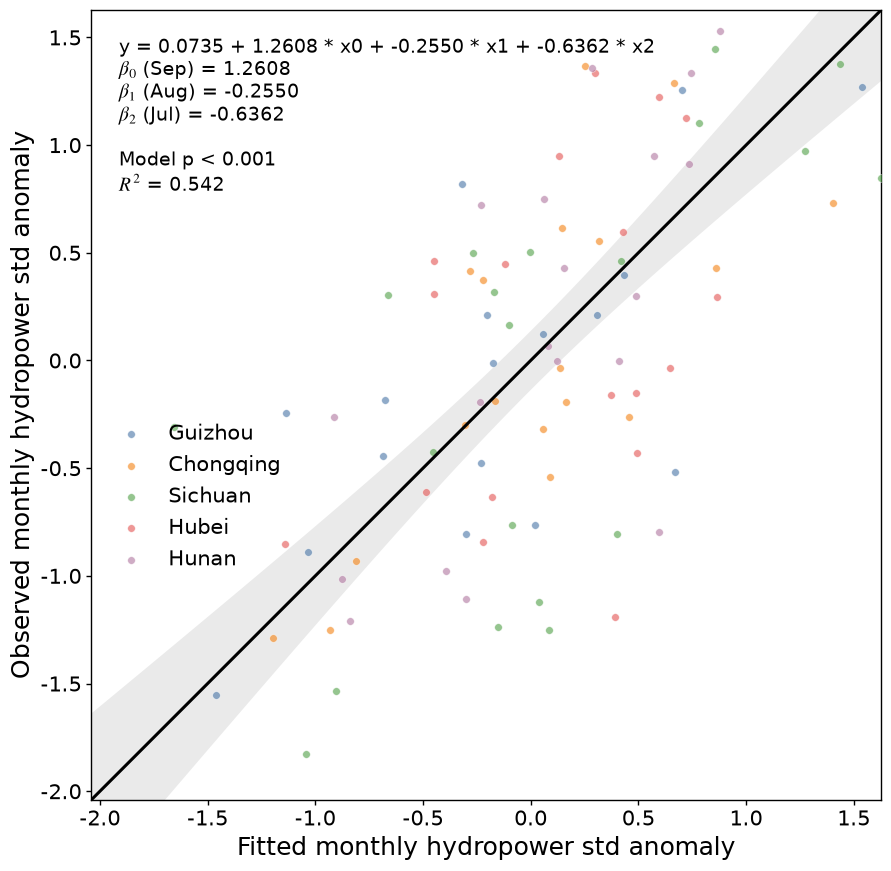

In [1]:
# Relationship function built using the 3 variables

import calendar
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from pathlib import Path

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# 1. User settings
# ============================================================

INPUT_DIR = "/home/users/weijia_6/Yangtze_code/gen_data/hydropower_anomaly"

PROVINCE_INFO = {
    "guizhou": {"name": "Guizhou", "panel": "(a)", "color": "#4C78A8"},
    "chongqing": {"name": "Chongqing", "panel": "(b)", "color": "#F58518"},
    "sichuan": {"name": "Sichuan", "panel": "(c)", "color": "#54A24B"},
    "hubei": {"name": "Hubei", "panel": "(d)", "color": "#E45756"},
    "hunan": {"name": "Hunan", "panel": "(e)", "color": "#B279A2"},
}

YEAR_START = 2002
YEAR_END = 2022
TARGET_MONTH = 9

# Use only lag 0, lag 1, lag 2
TIME_LAG = 2

HYDRO_ANOMALY_COL = "std_anomaly"
PRECIP_ANOMALY_COL = "spi_6"

# Output folder
out_dir = Path("/home/users/weijia_6/Yangtze_code/gen_result")
out_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2. Parameter checks
# ============================================================

if not isinstance(TARGET_MONTH, int) or isinstance(TARGET_MONTH, bool):
    raise ValueError("TARGET_MONTH must be an integer from 1 to 12.")

if TARGET_MONTH < 1 or TARGET_MONTH > 12:
    raise ValueError("TARGET_MONTH must be an integer from 1 to 12.")

if not isinstance(TIME_LAG, int) or isinstance(TIME_LAG, bool) or TIME_LAG < 0:
    raise ValueError("TIME_LAG must be a non-negative integer.")

if TIME_LAG > TARGET_MONTH - 1:
    raise ValueError(
        f"TARGET_MONTH={TARGET_MONTH}, TIME_LAG cannot exceed {TARGET_MONTH - 1}."
    )

LAG_LIST = list(range(TIME_LAG + 1))   # now: [0, 1, 2]
LAG_COLS = [f"{PRECIP_ANOMALY_COL}_lag{lag}" for lag in LAG_LIST]
N_LAG_TERMS = len(LAG_COLS)

# ============================================================
# 3. Plot settings
# ============================================================

FIGSIZE = (14, 10)
FIGURE_DPI = 600

SCATTER_SIZE = 30
SCATTER_ALPHA = 0.62
SCATTER_EDGE_WIDTH = 0.45

CALIBRATION_LINE_WIDTH = 2.2
REFERENCE_LINE_WIDTH = 1.3
CONFIDENCE_ALPHA = 0.18

TITLE_FONT_SIZE = 18
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
ANNOTATION_FONT_SIZE = 14

SHOW_95_CI = True
SHOW_GRID = False

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 15,
        "axes.unicode_minus": False,
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.0,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
    }
)

# ============================================================
# 4. General helpers
# ============================================================

def assert_exists(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Path not found:\n{path}")

def construct_month_date(df):
    return pd.to_datetime(
        {"year": df["year"], "month": df["month"], "day": 1},
        errors="coerce",
    )

def month_number_for_lag(lag):
    return TARGET_MONTH - lag

def month_name_for_lag(lag):
    return calendar.month_name[month_number_for_lag(lag)]

def target_month_name():
    return calendar.month_name[TARGET_MONTH]

def rainfall_window_text():
    start_month = month_name_for_lag(TIME_LAG)
    end_month = target_month_name()
    if TIME_LAG == 0:
        return end_month
    return f"{start_month}-{end_month}"

def significance_label(p):
    if not np.isfinite(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

def format_p_value(p):
    if not np.isfinite(p):
        return "NA"
    if p < 0.001:
        return "< 0.001"
    return f"= {p:.3f}"

def format_coefficient(value):
    if not np.isfinite(value):
        return "NA"
    abs_value = abs(value)
    if (0 < abs_value < 0.001) or abs_value >= 1000:
        return f"{value:.2e}"
    return f"{value:.4f}"

def beta_display_name(lag):
    return rf"$\beta_{{{lag}}}$"

# ============================================================
# 5. OLS + t/p/CI
# ============================================================

def fit_ols(y, X):
    n = len(y)
    X = np.column_stack([np.ones(n), X])  # add intercept
    model = LinearRegression(fit_intercept=False).fit(X, y)

    coef = model.coef_
    fitted = model.predict(X)
    residuals = y - fitted
    rss = np.sum(residuals**2)
    df = n - X.shape[1]

    XtX_inv = np.linalg.inv(X.T @ X)
    sigma2 = rss / df
    stderr = np.sqrt(np.diag(sigma2 * XtX_inv))

    tval = coef / stderr
    pval = 2 * (1 - stats.t.cdf(np.abs(tval), df))

    ci_low = coef - stats.t.ppf(0.975, df) * stderr
    ci_high = coef + stats.t.ppf(0.975, df) * stderr

    r2 = model.score(X, y)

    return {
        "coef": coef,
        "stderr": stderr,
        "tval": tval,
        "pval": pval,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "fitted": fitted,
        "residuals": residuals,
        "r2": r2,
    }

def durbin_watson(residuals):
    diff = np.diff(residuals)
    return np.sum(diff**2) / np.sum(residuals**2)

def calculate_vif(X):
    vif_list = []
    for i in range(X.shape[1]):
        y = X[:, i]
        X_others = np.delete(X, i, axis=1)
        model = LinearRegression().fit(X_others, y)
        r2 = model.score(X_others, y)
        vif = 1.0 / (1.0 - r2)
        vif_list.append(vif)
    return vif_list

# ============================================================
# 6. Overall model p-value
# ============================================================

def overall_model_pvalue(result, X, y):
    n = len(y)
    k = X.shape[1]

    fitted = result["fitted"]
    residuals = result["residuals"]

    rss = np.sum(residuals**2)
    tss = np.sum((y - np.mean(y))**2)
    reg_ss = tss - rss

    df_reg = k
    df_resid = n - (k + 1)

    ms_reg = reg_ss / df_reg
    ms_resid = rss / df_resid

    F = ms_reg / ms_resid
    p = 1 - stats.f.cdf(F, df_reg, df_resid)
    return p

# ============================================================
# 7. Regression equation
# ============================================================

def build_regression_equation(result):
    coef = result["coef"]
    terms = [f"{coef[0]:.4f}"]
    for lag in LAG_LIST:
        terms.append(f"{coef[lag + 1]:.4f} * x{lag}")
    return "y = " + " + ".join(terms)

# ============================================================
# 8. Calibration band
# ============================================================

def calculate_calibration_band(fitted, observed, confidence=0.95, grid_size=300):
    x = fitted
    y = observed
    n = len(x)

    X = np.column_stack([np.ones(n), x])
    beta = np.linalg.inv(X.T @ X) @ (X.T @ y)

    y_hat = X @ beta
    residuals = y - y_hat
    rss = np.sum(residuals**2)
    df = n - 2
    sigma2 = rss / df

    x_grid = np.linspace(min(x), max(x), grid_size)
    Xg = np.column_stack([np.ones(grid_size), x_grid])
    mean = Xg @ beta

    XtX_inv = np.linalg.inv(X.T @ X)
    se_mean = np.sqrt(np.sum(Xg @ XtX_inv * Xg, axis=1) * sigma2)

    tcrit = stats.t.ppf(1 - (1 - confidence) / 2, df)
    lower = mean - tcrit * se_mean
    upper = mean + tcrit * se_mean

    return {
        "x_grid": x_grid,
        "mean": mean,
        "lower": lower,
        "upper": upper,
        "plot_min": min(x),
        "plot_max": max(x),
    }

# ============================================================
# 9. Annotation
# ============================================================

def build_annotation_text(result, X, y):
    coef = result["coef"]
    r2 = result["r2"]
    p_model = overall_model_pvalue(result, X, y)

    lines = []
    eq = build_regression_equation(result)
    lines.append("\n" + eq)

    for lag in LAG_LIST:
        idx = lag + 1
        b = coef[idx]
        lines.append(
            f"{beta_display_name(lag)} ({month_name_for_lag(lag)[:3]}) = "
            f"{format_coefficient(b)}"
        )

    lines.append(f"\nModel p {format_p_value(p_model)}")
    lines.append(rf"$R^2$ = {r2:.3f}")

    return "\n".join(lines)

# ============================================================
# 10. Data loading
# ============================================================

def build_input_path(province_key):
    filename = f"{province_key}_hydro_anomaly_and_std_in_reg.csv"
    return os.path.join(INPUT_DIR, filename)

def load_one_province(province_key, province_name):
    input_path = build_input_path(province_key)
    assert_exists(input_path)

    df = pd.read_csv(input_path, encoding="utf-8-sig")
    df.columns = df.columns.astype(str).str.strip()

    required_columns = {"year", "month", HYDRO_ANOMALY_COL, PRECIP_ANOMALY_COL}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(
            f"{province_name} file is missing required variables: {sorted(missing_columns)}\n"
            f"File: {input_path}\n"
            f"Available columns: {list(df.columns)}"
        )

    df = df.copy()
    numeric_columns = ["year", "month", HYDRO_ANOMALY_COL, PRECIP_ANOMALY_COL]
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["year"] = df["year"].astype(int)
    df["month"] = df["month"].astype(int)
    df["date_month"] = construct_month_date(df)

    df = df.replace([np.inf, -np.inf], np.nan)

    duplicate_mask = df["date_month"].duplicated(keep=False)
    if duplicate_mask.any():
        df = (
            df.sort_values("date_month")
            .drop_duplicates(subset=["date_month"], keep="last")
            .reset_index(drop=True)
        )
    else:
        df = df.sort_values("date_month").reset_index(drop=True)

    full_month_index = pd.date_range(
        start=df["date_month"].min(),
        end=df["date_month"].max(),
        freq="MS",
    )
    monthly = df.set_index("date_month").reindex(full_month_index)
    monthly.index.name = "date_month"

    # lag0, lag1, lag2 only
    for lag, lag_col in zip(LAG_LIST, LAG_COLS):
        monthly[lag_col] = monthly[PRECIP_ANOMALY_COL].shift(lag)

    monthly = monthly.reset_index()
    monthly["year_for_filter"] = monthly["date_month"].dt.year
    monthly["month_for_filter"] = monthly["date_month"].dt.month

    regression_data = monthly.loc[
        (monthly["year_for_filter"] >= YEAR_START)
        & (monthly["year_for_filter"] <= YEAR_END)
        & (monthly["month_for_filter"] == TARGET_MONTH)
    ].copy()

    regression_data = regression_data.dropna(subset=[HYDRO_ANOMALY_COL, *LAG_COLS])

    regression_data["province_key"] = province_key
    regression_data["province_name"] = province_name

    return regression_data.sort_values("date_month").reset_index(drop=True)

# ============================================================
# 11. Combine five provinces
# ============================================================

def combine_province_data(province_data):
    pooled_data = (
        pd.concat([province_data[key] for key in PROVINCE_INFO], axis=0)
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[HYDRO_ANOMALY_COL, *LAG_COLS])
        .sort_values(["province_key", "date_month"])
        .reset_index(drop=True)
    )
    return pooled_data

# ============================================================
# 12. Plot
# ============================================================

def plot_pooled_provinces(ax, pooled_data, result, X, y):
    fitted = result["fitted"]
    observed = pooled_data[HYDRO_ANOMALY_COL].to_numpy()

    calibration = calculate_calibration_band(fitted, observed)

    for province_key, info in PROVINCE_INFO.items():
        subset = pooled_data.loc[pooled_data["province_key"] == province_key]
        ax.scatter(
            subset["fitted"],
            subset["observed"],
            s=SCATTER_SIZE,
            alpha=SCATTER_ALPHA,
            facecolor=info["color"],
            edgecolor="white",
            linewidth=SCATTER_EDGE_WIDTH,
            label=info["name"],
            zorder=3,
        )

    if SHOW_95_CI:
        ax.fill_between(
            calibration["x_grid"],
            calibration["lower"],
            calibration["upper"],
            color="0.55",
            alpha=CONFIDENCE_ALPHA,
            linewidth=0,
            zorder=1,
        )

    ax.plot(
        calibration["x_grid"],
        calibration["mean"],
        color="black",
        linewidth=CALIBRATION_LINE_WIDTH,
        zorder=4,
    )

    ax.plot(
        [calibration["plot_min"], calibration["plot_max"]],
        [calibration["plot_min"], calibration["plot_max"]],
        color="0.45",
        linewidth=REFERENCE_LINE_WIDTH,
        linestyle="--",
        zorder=2,
    )

    ax.set_xlim(calibration["plot_min"], calibration["plot_max"])
    ax.set_ylim(calibration["plot_min"], calibration["plot_max"])
    ax.set_aspect("auto")
    ax.set_box_aspect(1)

    ax.set_xlabel("Fitted monthly hydropower std anomaly", fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel("Observed monthly hydropower std anomaly", fontsize=LABEL_FONT_SIZE)

    ax.text(
        0.035,
        0.995,
        build_annotation_text(result, X, y),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=ANNOTATION_FONT_SIZE,
        linespacing=1.16,
        zorder=10,
    )

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.0, 0.5),
        fontsize=15.0,
        frameon=False,
    )

# ============================================================
# 13. Main
# ============================================================

def main():
    assert_exists(INPUT_DIR)

    province_data = {}
    for province_key, info in PROVINCE_INFO.items():
        province_data[province_key] = load_one_province(province_key, info["name"])

    pooled_data = combine_province_data(province_data)

    y = pooled_data[HYDRO_ANOMALY_COL].to_numpy(dtype=float)
    X = pooled_data[LAG_COLS].to_numpy(dtype=float)

    result = fit_ols(y, X)
    pooled_data["fitted"] = result["fitted"]
    pooled_data["observed"] = y

    print("\nRegression equation:")
    print(build_regression_equation(result))

    fig, ax = plt.subplots(figsize=FIGSIZE)
    plot_pooled_provinces(ax, pooled_data, result, X, y)

    plt.subplots_adjust(left=0.12, right=0.965, bottom=0.12, top=0.91)
    plt.savefig(
        out_dir / "Relationship between hydro std anomaly and SPI6.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

if __name__ == "__main__":
    main()